In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = {
    "CustomerID": range(1, 21),

    "CustomerName": [
        "Rahul", "Priya", "Amit", "Sneha", "Rohan",
        "Anjali", "Vikash", "Neha", "Arjun", "Pooja",
        "Karan", "Riya", "Aditya", "Nisha", "Sahil",
        "Kavya", "Manish", "Simran", "Ravi", "Isha"
    ],

    "Total_Spending": [
        85000, 72000, 15000, 22000, 95000,
        18000, 65000, 42000, 12000, 55000,
        78000, 25000, 90000, 35000, 14000,
        68000, 30000, 82000, 20000, 48000
    ],

    "Purchase_Frequency": [
        18, 15, 4, 5, 20,
        3, 14, 10, 2, 12,
        17, 6, 19, 8, 3,
        13, 7, 16, 5, 11
    ]
}

df = pd.DataFrame(data)

df

,CustomerID,CustomerName,Total_Spending,Purchase_Frequency
0,1,Rahul,85000,18
1,2,Priya,72000,15
2,3,Amit,15000,4
3,4,Sneha,22000,5
4,5,Rohan,95000,20
5,6,Anjali,18000,3
6,7,Vikash,65000,14
7,8,Neha,42000,10
8,9,Arjun,12000,2
9,10,Pooja,55000,12


In [4]:
print("Number of Customers:", len(df))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df[["Total_Spending", "Purchase_Frequency"]].describe())

Number of Customers: 20

Missing Values:
CustomerID            0
CustomerName          0
Total_Spending        0
Purchase_Frequency    0
dtype: int64

Basic Statistics:
       Total_Spending  Purchase_Frequency
count       20.000000           20.000000
mean     48550.000000           10.400000
std      28713.603965            5.888436
min      12000.000000            2.000000
25%      21500.000000            5.000000
50%      45000.000000           10.500000
75%      73500.000000           15.250000
max      95000.000000           20.000000


In [5]:
def segment_customer(row):

    spending = row["Total_Spending"]
    frequency = row["Purchase_Frequency"]

    if spending >= 60000 and frequency >= 12:
        return "High Value Customer"

    elif spending >= 30000 and frequency >= 7:
        return "Regular Customer"

    else:
        return "Low Value Customer"


df["Segment"] = df.apply(segment_customer, axis=1)

df

,CustomerID,CustomerName,Total_Spending,Purchase_Frequency,Segment
0,1,Rahul,85000,18,High Value Customer
1,2,Priya,72000,15,High Value Customer
2,3,Amit,15000,4,Low Value Customer
3,4,Sneha,22000,5,Low Value Customer
4,5,Rohan,95000,20,High Value Customer
5,6,Anjali,18000,3,Low Value Customer
6,7,Vikash,65000,14,High Value Customer
7,8,Neha,42000,10,Regular Customer
8,9,Arjun,12000,2,Low Value Customer
9,10,Pooja,55000,12,Regular Customer


In [6]:
segment_summary = df.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Average_Spending=("Total_Spending", "mean"),
    Average_Purchases=("Purchase_Frequency", "mean")
).round(2)

segment_summary

,Customers,Average_Spending,Average_Purchases
Segment,,,
High Value Customer,8,79375.0,16.5
Low Value Customer,7,18000.0,4.0
Regular Customer,5,42000.0,9.6


In [7]:
segment_counts = df["Segment"].value_counts()

print(segment_counts)

Segment
High Value Customer    8
Low Value Customer     7
Regular Customer       5
Name: count, dtype: int64


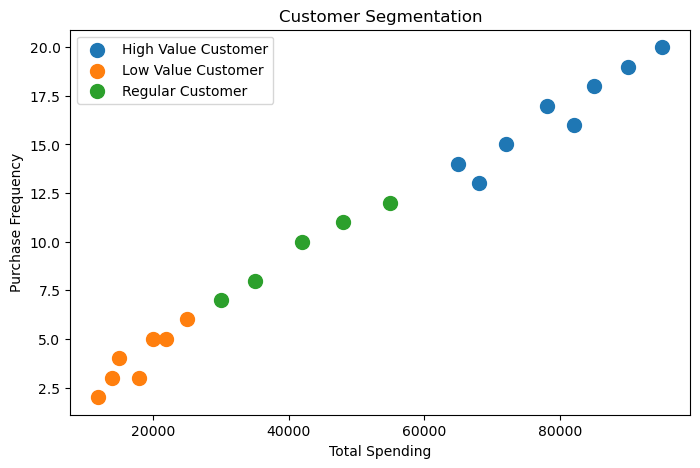

In [8]:
plt.figure(figsize=(8, 5))

for segment in df["Segment"].unique():

    segment_data = df[df["Segment"] == segment]

    plt.scatter(
        segment_data["Total_Spending"],
        segment_data["Purchase_Frequency"],
        label=segment,
        s=100
    )

plt.title("Customer Segmentation")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")
plt.legend()

plt.show()